# Data Loading and Pre-processing

In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("train(1).xlsx")
print("Initial shape:", df.shape)


Initial shape: (16209, 21)


In [2]:
# Drop missing values
df = df.dropna()

# Remove non-positive prices
df = df[df["price"] > 0]

print("After cleaning:", df.shape)

After cleaning: (16209, 21)


# Feature Engineering 

In [3]:
df = df.drop(columns=["id", "zipcode"], errors="ignore")

In [4]:
df["date"] = pd.to_datetime(df["date"])

df["year_sold"] = df["date"].dt.year
df["month_sold"] = df["date"].dt.month

df = df.drop(columns=["date"])

In [5]:
df["renovated_flag"] = (df["yr_renovated"] > 0).astype(int)

df["house_age"] = df["year_sold"] - df["yr_built"]


In [6]:
# log scale (VERY IMPORTANT)
df["log_sqft_living"] = np.log1p(df["sqft_living"])

# ratios
df["sqft_per_bed"] = df["sqft_living"] / (df["bedrooms"] + 1)
df["bath_per_bed"] = df["bathrooms"] / (df["bedrooms"] + 1)

# structure ratios
df["above_ratio"] = df["sqft_above"] / (df["sqft_living"] + 1)


In [7]:
lat_center = df["lat"].mean()
lon_center = df["long"].mean()

df["dist_center"] = np.sqrt(
    (df["lat"] - lat_center)**2 +
    (df["long"] - lon_center)**2
)

df["lat_long"] = df["lat"] * df["long"]


In [8]:
df["log_price"] = np.log(df["price"])



In [9]:
drop_cols = [
    "price",
    "sqft_living",
    "sqft_above",
    "yr_built",
    "yr_renovated"
]

df = df.drop(columns=drop_cols)



In [10]:
df.columns


Index(['bedrooms', 'bathrooms', 'sqft_lot', 'floors', 'waterfront', 'view',
       'condition', 'grade', 'sqft_basement', 'lat', 'long', 'sqft_living15',
       'sqft_lot15', 'year_sold', 'month_sold', 'renovated_flag', 'house_age',
       'log_sqft_living', 'sqft_per_bed', 'bath_per_bed', 'above_ratio',
       'dist_center', 'lat_long', 'log_price'],
      dtype='object')

# EDA & Geospatial Analysis ( Including Financial/Visual Insights )

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


In [12]:
df = df.copy()   # safety
print(df.shape)
df.head()


(16209, 24)


,bedrooms,bathrooms,sqft_lot,floors,waterfront,view,condition,grade,sqft_basement,lat,...,month_sold,renovated_flag,house_age,log_sqft_living,sqft_per_bed,bath_per_bed,above_ratio,dist_center,lat_long,log_price
0,4,2.25,9240,2.0,0,0,3,7,0,47.4362,...,5,0,54,7.501634,362.000000,0.450,0.999448,0.127401,-5796.086969,12.501139
1,3,2.50,2788,2.0,0,0,4,7,0,47.4034,...,7,0,22,7.378384,400.000000,0.625,0.999375,0.159607,-5792.079236,12.409013
2,4,2.50,8638,2.0,0,0,3,8,0,47.2704,...,1,0,21,7.450661,344.000000,0.500,0.999419,0.306722,-5781.784435,12.206073
3,2,2.25,705,2.0,0,0,3,7,90,47.5321,...,4,0,6,7.123673,413.333333,0.750,0.926672,0.143876,-5802.386043,12.772803
4,3,2.00,13356,1.0,0,0,3,7,0,47.3715,...,12,0,20,7.155396,320.000000,0.500,0.999219,0.235372,-5782.828491,12.354493


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


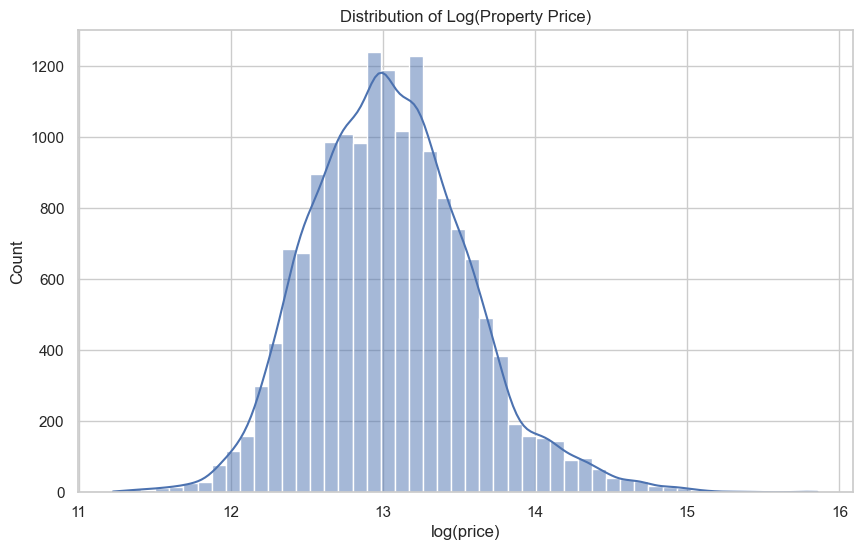

In [13]:
#1.1 Distribution of log_price (WHY log transform)

sns.histplot(df["log_price"], kde=True, bins=50)
plt.title("Distribution of Log(Property Price)")
plt.xlabel("log(price)")
plt.show()



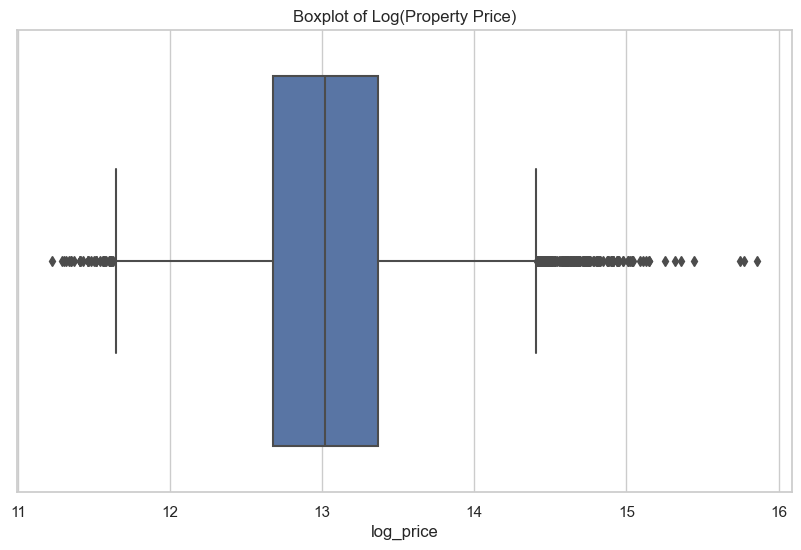

In [14]:
#1.2 Boxplot – Outlier behavior
sns.boxplot(x=df["log_price"])
plt.title("Boxplot of Log(Property Price)")
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


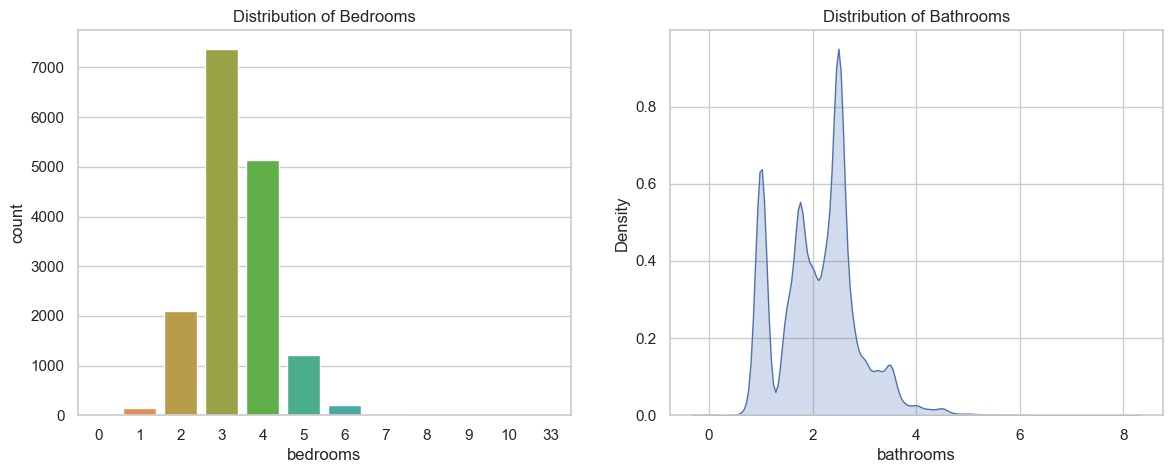

In [15]:
#2.1 Bedrooms & Bathrooms (bar + KDE)
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.countplot(x="bedrooms", data=df, ax=ax[0])
ax[0].set_title("Distribution of Bedrooms")

sns.kdeplot(x="bathrooms", data=df, fill=True, ax=ax[1])
ax[1].set_title("Distribution of Bathrooms")

plt.show()


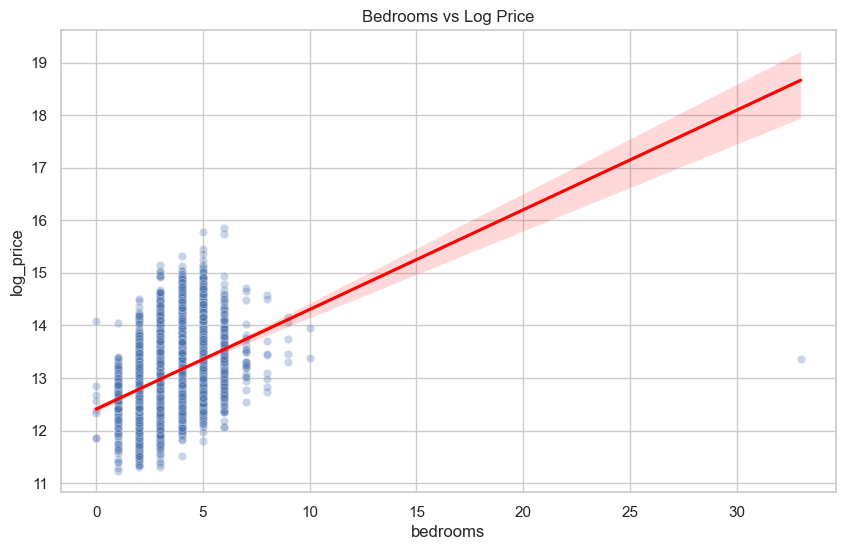

In [16]:
#2.2 Bedrooms vs log_price (scatter + trend)
sns.scatterplot(x="bedrooms", y="log_price", data=df, alpha=0.3)
sns.regplot(x="bedrooms", y="log_price", data=df, scatter=False, color="red")
plt.title("Bedrooms vs Log Price")
plt.show()


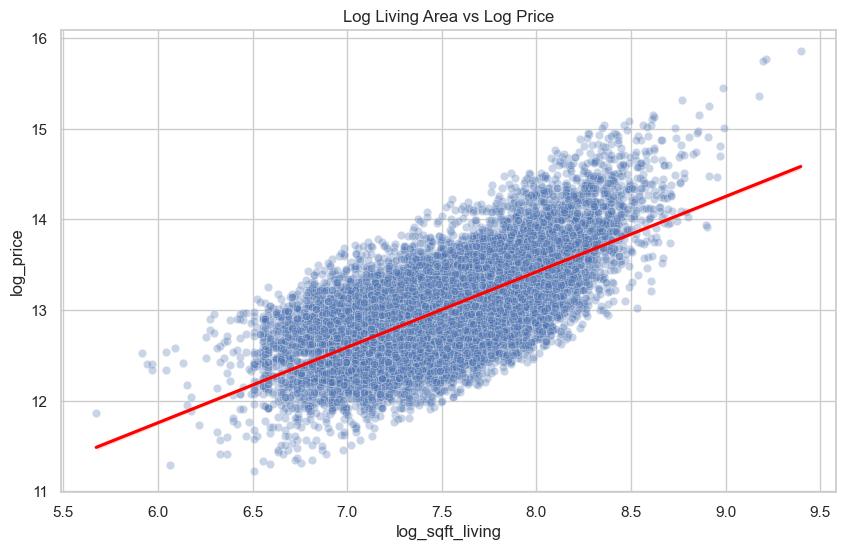

In [17]:
#3.1 log_sqft_living vs log_price (VERY IMPORTANT)
sns.scatterplot(
    x="log_sqft_living",
    y="log_price",
    data=df,
    alpha=0.3
)
sns.regplot(
    x="log_sqft_living",
    y="log_price",
    data=df,
    scatter=False,
    color="red"
)
plt.title("Log Living Area vs Log Price")
plt.show()



/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


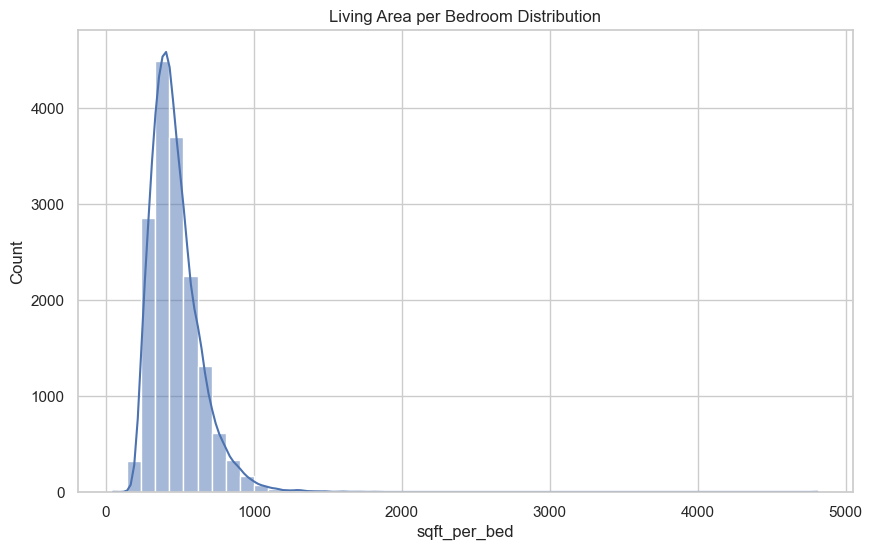

In [18]:
#3.2 sqft_per_bed (efficiency feature)
sns.histplot(df["sqft_per_bed"], bins=50, kde=True)
plt.title("Living Area per Bedroom Distribution")
plt.show()



/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


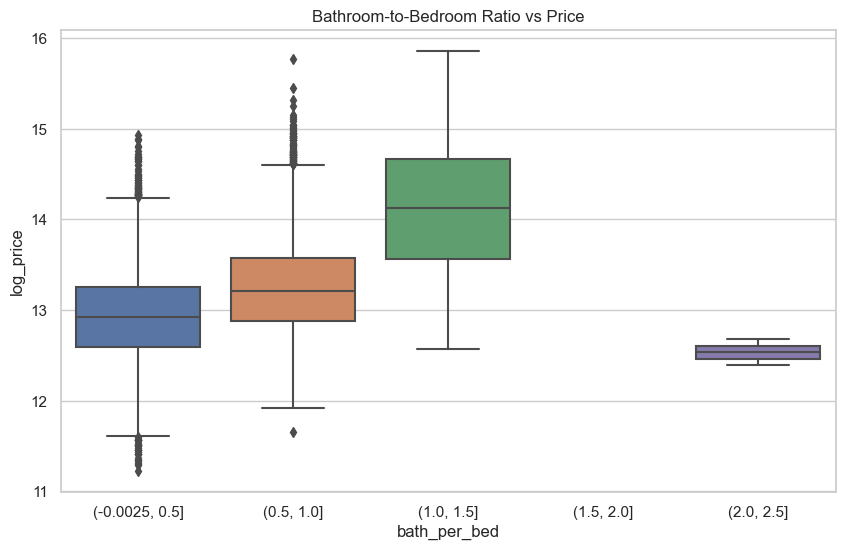

In [19]:
#3.3 bath_per_bed vs log_price
sns.boxplot(
    x=pd.cut(df["bath_per_bed"], bins=5),
    y=df["log_price"]
)
plt.title("Bathroom-to-Bedroom Ratio vs Price")
plt.show()



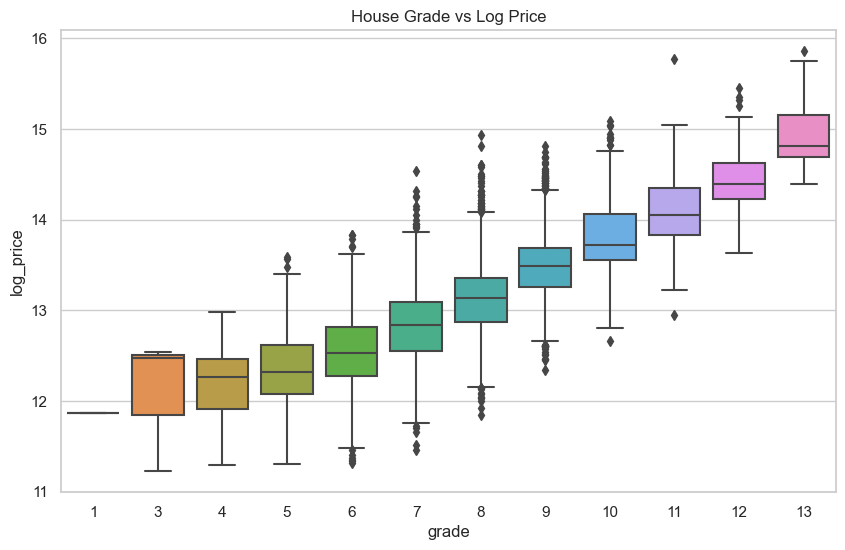

In [20]:
#4.1 Grade vs Price (boxplot)
sns.boxplot(x="grade", y="log_price", data=df)
plt.title("House Grade vs Log Price")
plt.show()


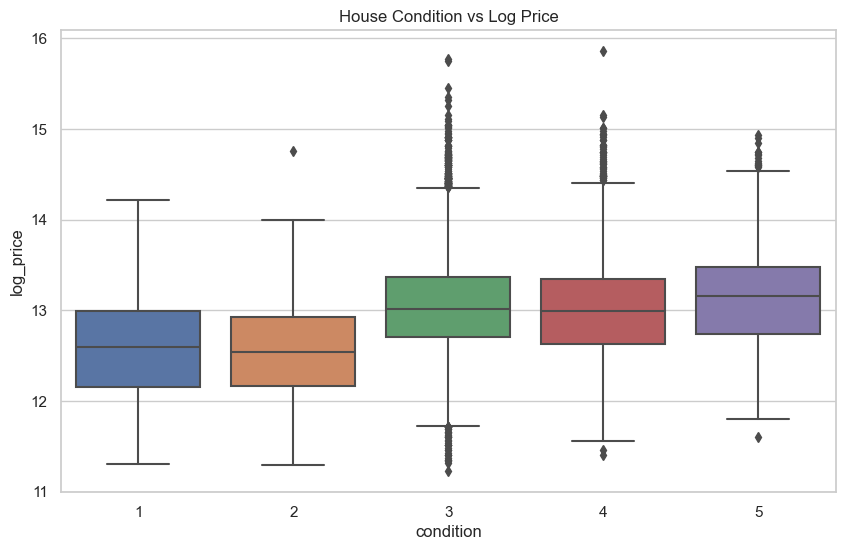

In [21]:
#4.2 Condition vs Price
sns.boxplot(x="condition", y="log_price", data=df)
plt.title("House Condition vs Log Price")
plt.show()


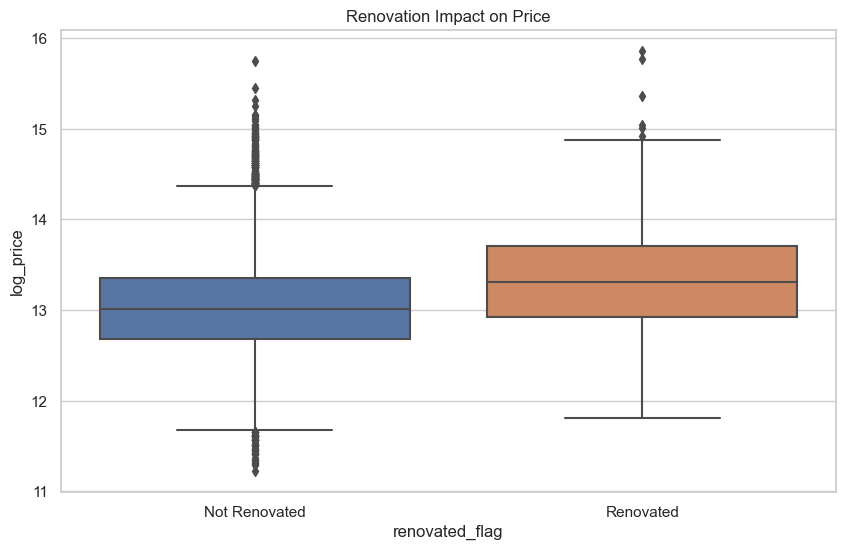

In [22]:
#5.1 Renovated vs Not Renovated
sns.boxplot(x="renovated_flag", y="log_price", data=df)
plt.xticks([0,1], ["Not Renovated", "Renovated"])
plt.title("Renovation Impact on Price")
plt.show()


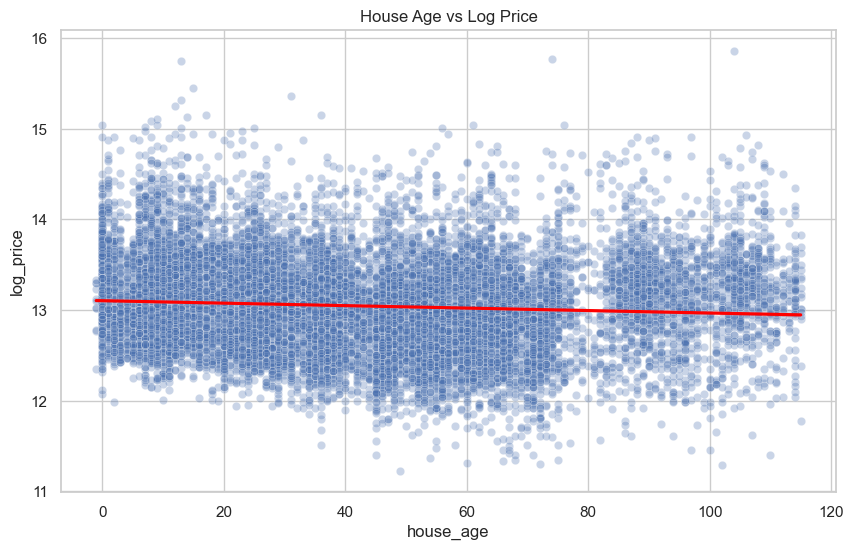

In [23]:
#5.2 House Age vs Price
sns.scatterplot(x="house_age", y="log_price", data=df, alpha=0.3)
sns.regplot(x="house_age", y="log_price", data=df, scatter=False, color="red")
plt.title("House Age vs Log Price")
plt.show()


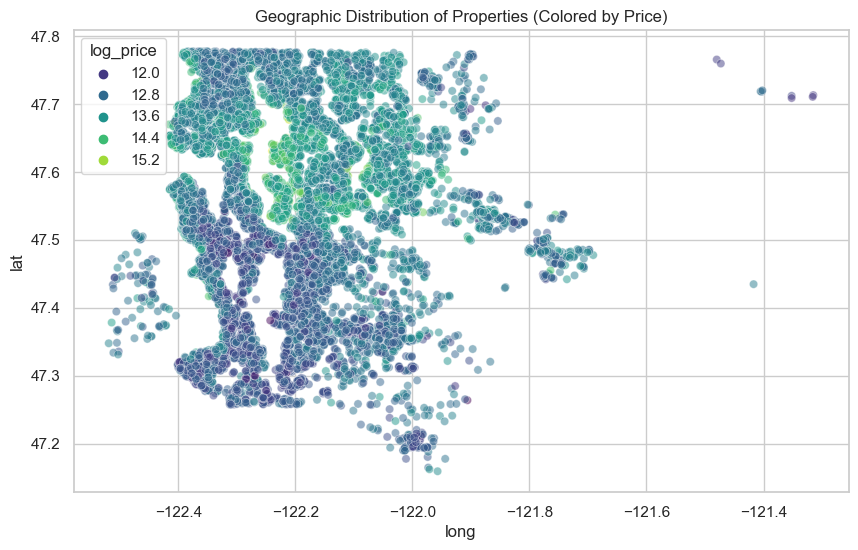

In [24]:
#6.1 Latitude & Longitude Scatter (density)
sns.scatterplot(
    x="long",
    y="lat",
    hue="log_price",
    data=df,
    palette="viridis",
    alpha=0.5
)
plt.title("Geographic Distribution of Properties (Colored by Price)")
plt.show()


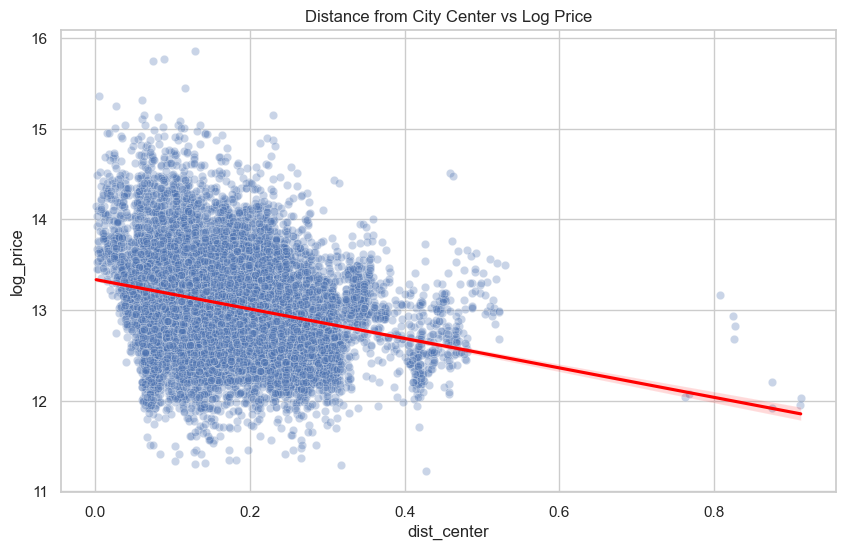

In [25]:
#6.2 Distance from Center vs Price
sns.scatterplot(
    x="dist_center",
    y="log_price",
    data=df,
    alpha=0.3
)
sns.regplot(
    x="dist_center",
    y="log_price",
    data=df,
    scatter=False,
    color="red"
)
plt.title("Distance from City Center vs Log Price")
plt.show()


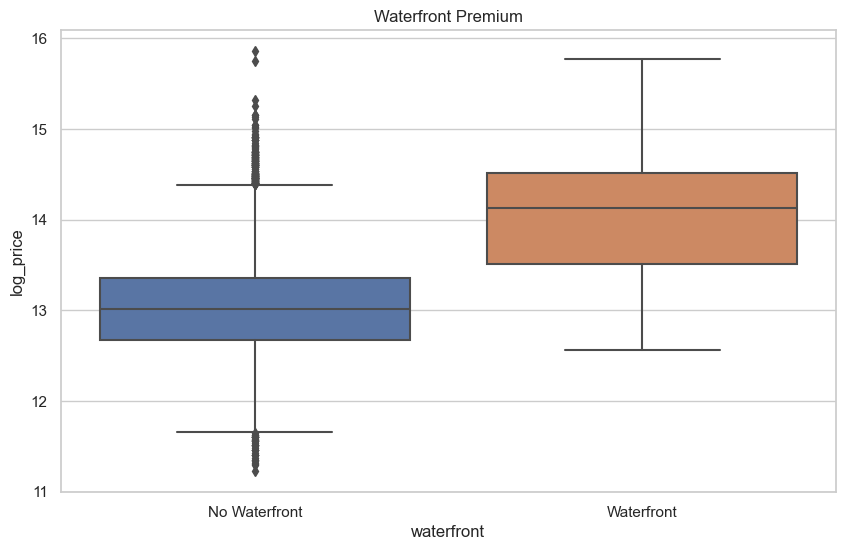

In [26]:
#6.3 Waterfront Effect
sns.boxplot(x="waterfront", y="log_price", data=df)
plt.xticks([0,1], ["No Waterfront", "Waterfront"])
plt.title("Waterfront Premium")
plt.show()


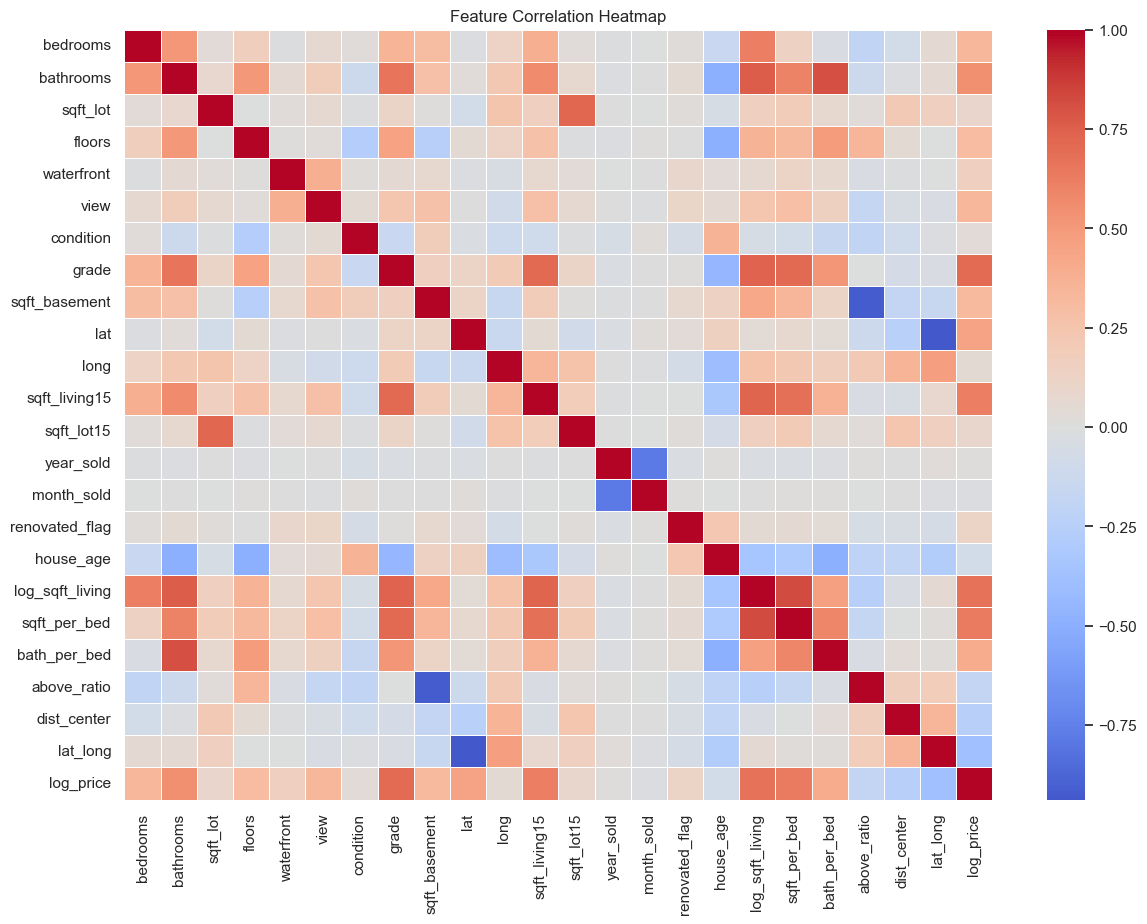

In [27]:
#7.1 Heatmap (multicollinearity insight)
plt.figure(figsize=(14,10))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

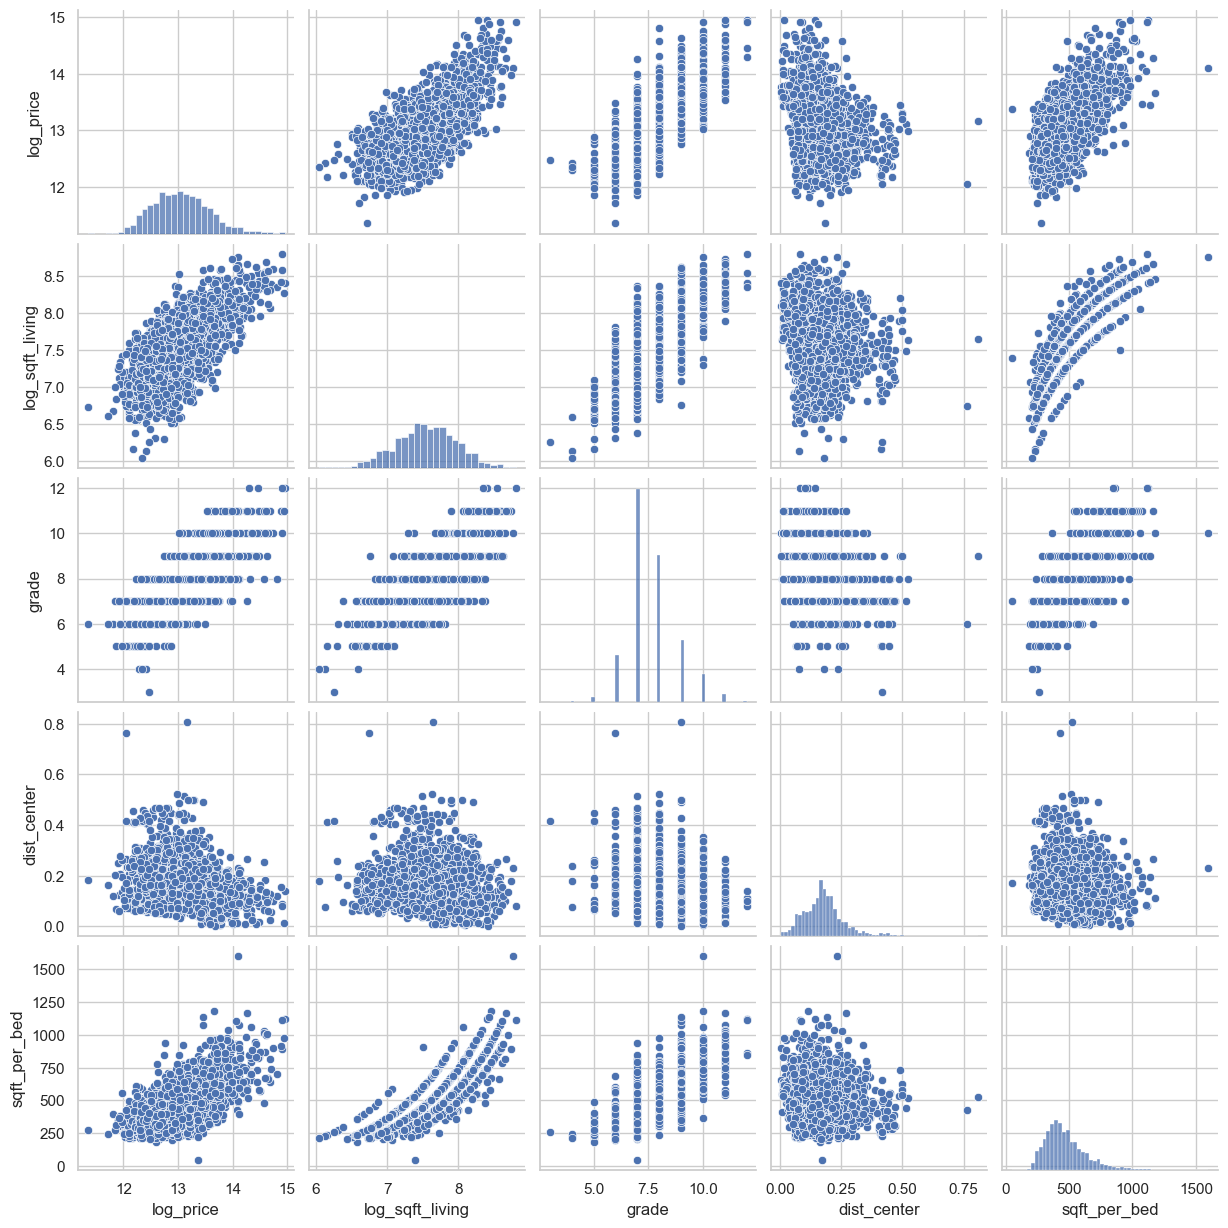

In [28]:
sample_df = df.sample(2000, random_state=42)

sns.pairplot(
    sample_df,
    vars=[
        "log_price",
        "log_sqft_living",
        "grade",
        "dist_center",
        "sqft_per_bed"
    ]
)
plt.show()


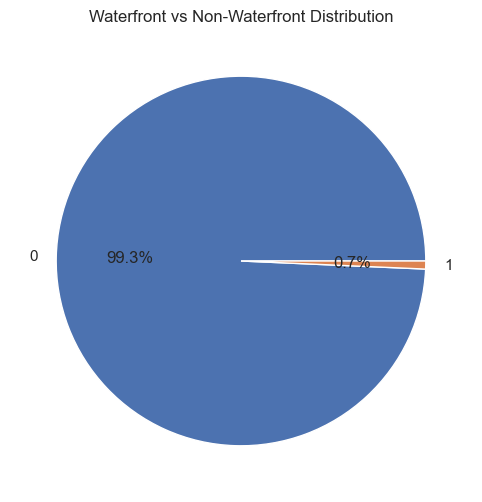

In [29]:
df["waterfront"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Waterfront vs Non-Waterfront Distribution")
plt.ylabel("")
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


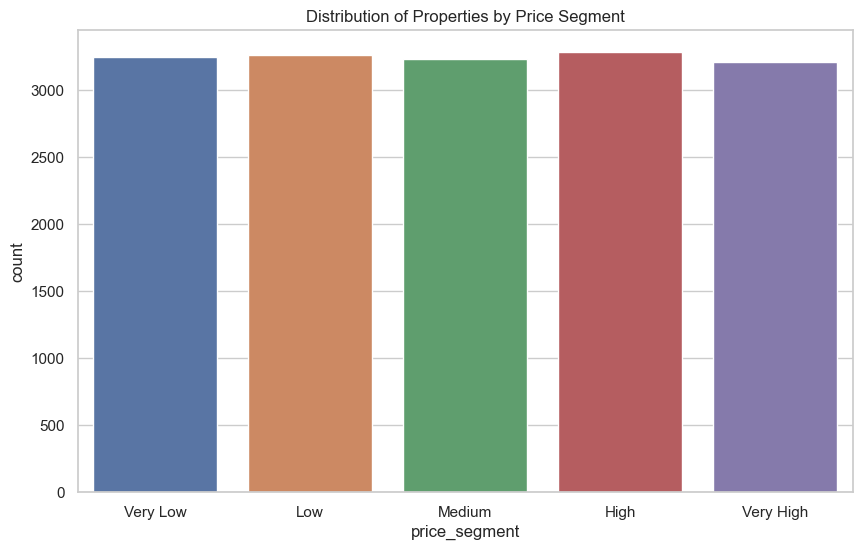

In [30]:
#10.1 Price Quantile Segmentation
df["price_segment"] = pd.qcut(
    df["log_price"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)
sns.countplot(x="price_segment", data=df)
plt.title("Distribution of Properties by Price Segment")
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


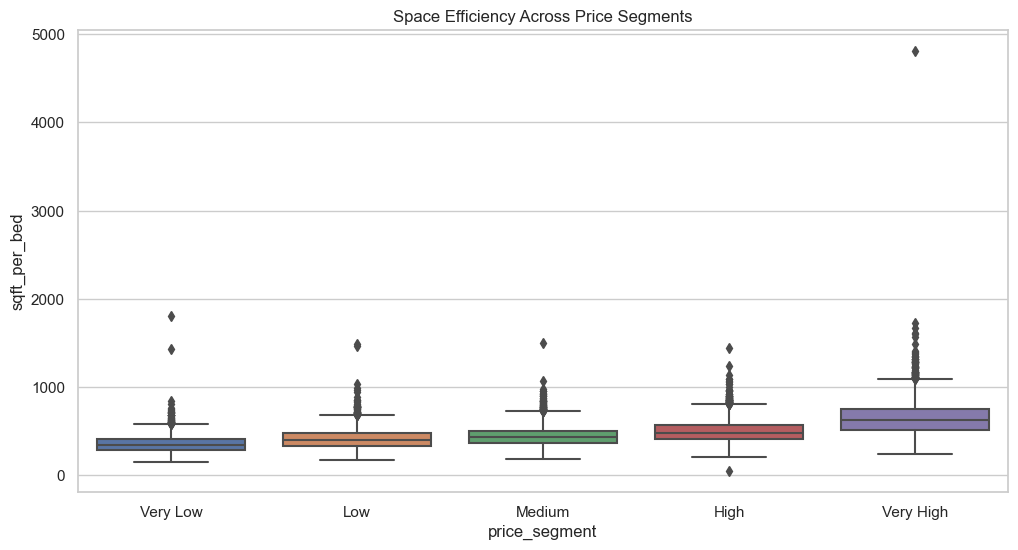

In [31]:
#10.2 Feature behavior across price segments
plt.figure(figsize=(12,6))
sns.boxplot(x="price_segment", y="sqft_per_bed", data=df)
plt.title("Space Efficiency Across Price Segments")
plt.show()


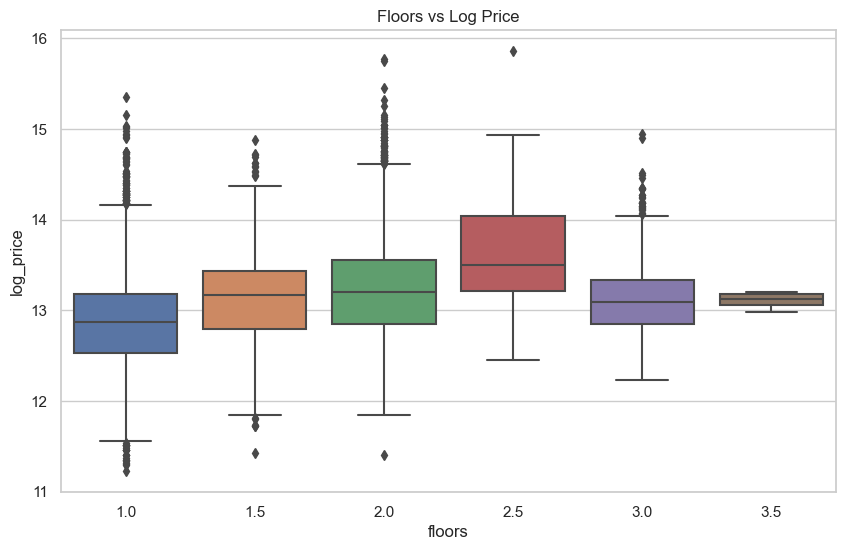

In [32]:
#11.1 Floors vs Price
sns.boxplot(x="floors", y="log_price", data=df)
plt.title("Floors vs Log Price")
plt.show()



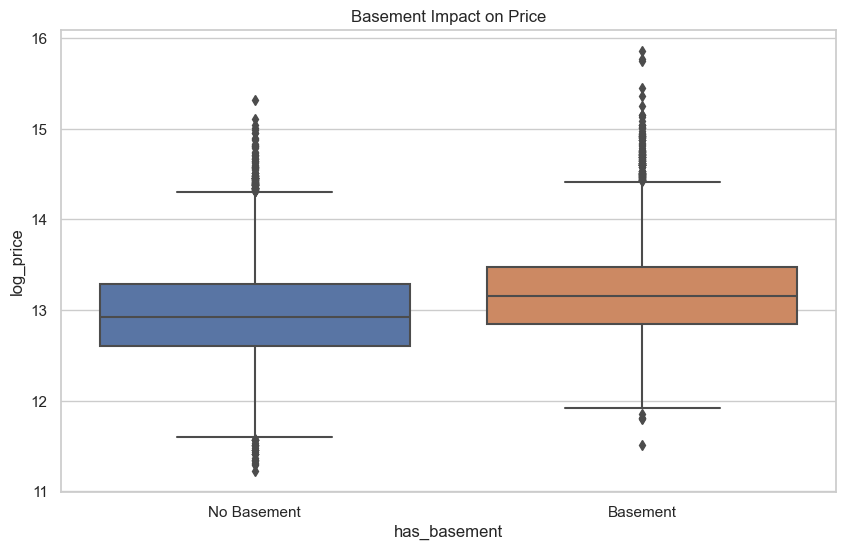

In [33]:
# 11.2 Basement Presence Effect
df["has_basement"] = (df["sqft_basement"] > 0).astype(int)

sns.boxplot(x="has_basement", y="log_price", data=df)
plt.xticks([0,1], ["No Basement", "Basement"])
plt.title("Basement Impact on Price")
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


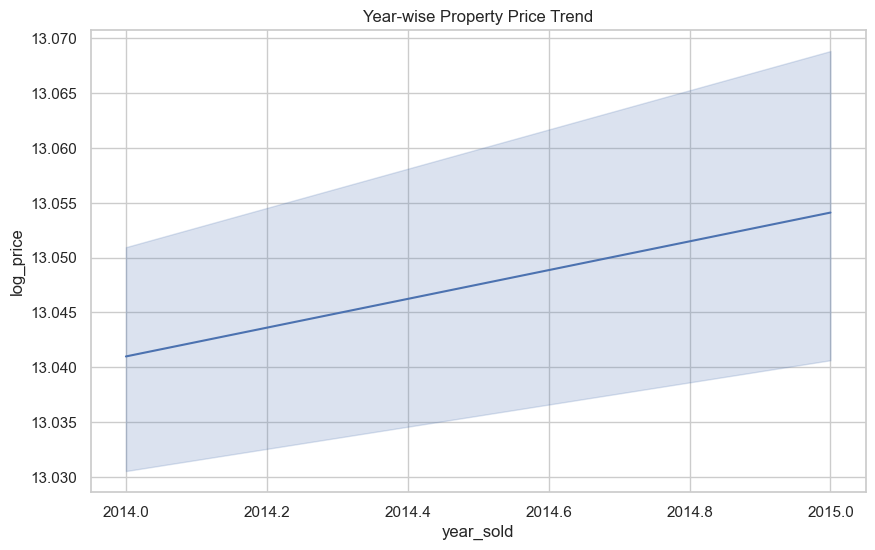

In [34]:
#12.1 Yearly Price Trend
sns.lineplot(x="year_sold", y="log_price", data=df)
plt.title("Year-wise Property Price Trend")
plt.show()


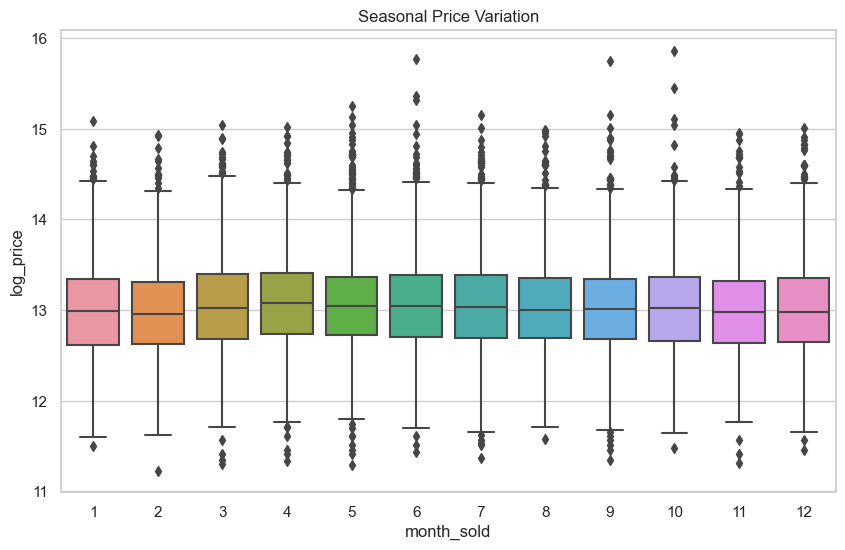

In [35]:
#12.2 Seasonal Effects (Month Sold)
sns.boxplot(x="month_sold", y="log_price", data=df)
plt.title("Seasonal Price Variation")
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


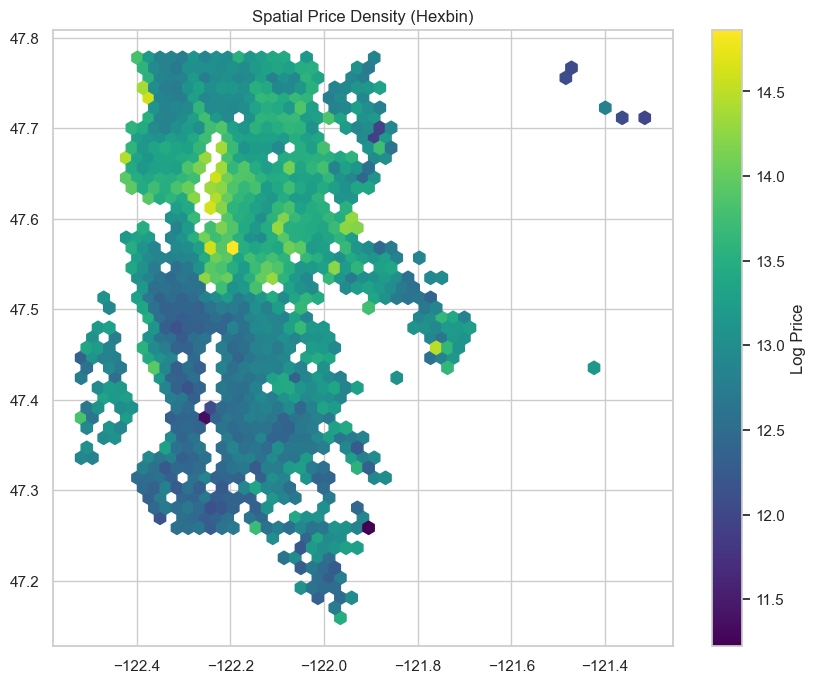

In [36]:
#13.1 Price Heatmap via Hexbins
plt.figure(figsize=(10,8))
plt.hexbin(
    df["long"],
    df["lat"],
    C=df["log_price"],
    gridsize=50,
    cmap="viridis"
)
plt.colorbar(label="Log Price")
plt.title("Spatial Price Density (Hexbin)")
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


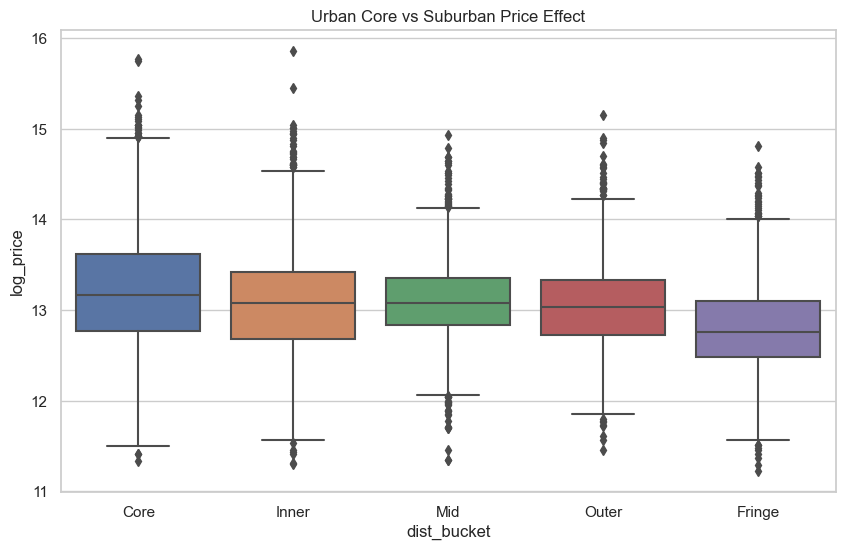

In [37]:
#13.2 Distance Bucketing
df["dist_bucket"] = pd.qcut(
    df["dist_center"],
    q=5,
    labels=["Core", "Inner", "Mid", "Outer", "Fringe"]
)

sns.boxplot(x="dist_bucket", y="log_price", data=df)
plt.title("Urban Core vs Suburban Price Effect")
plt.show()


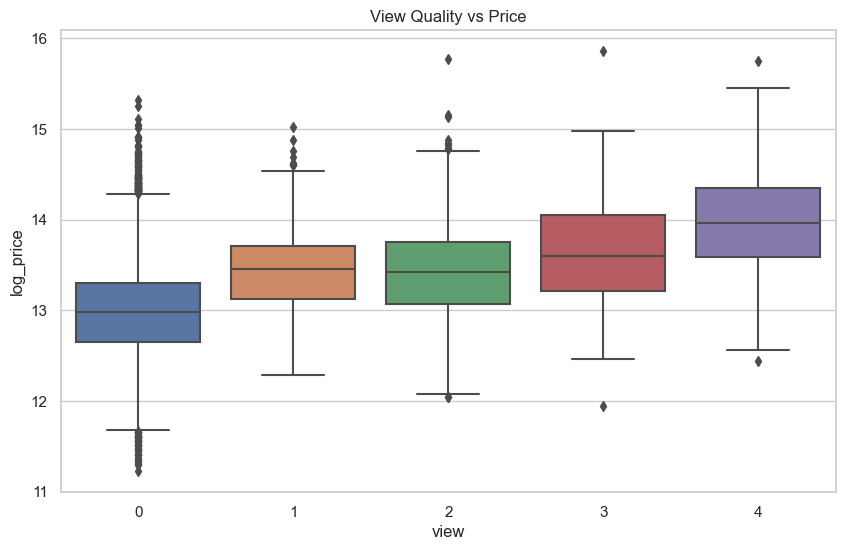

In [38]:
#14.1 View Score vs Price
sns.boxplot(x="view", y="log_price", data=df)
plt.title("View Quality vs Price")
plt.show()



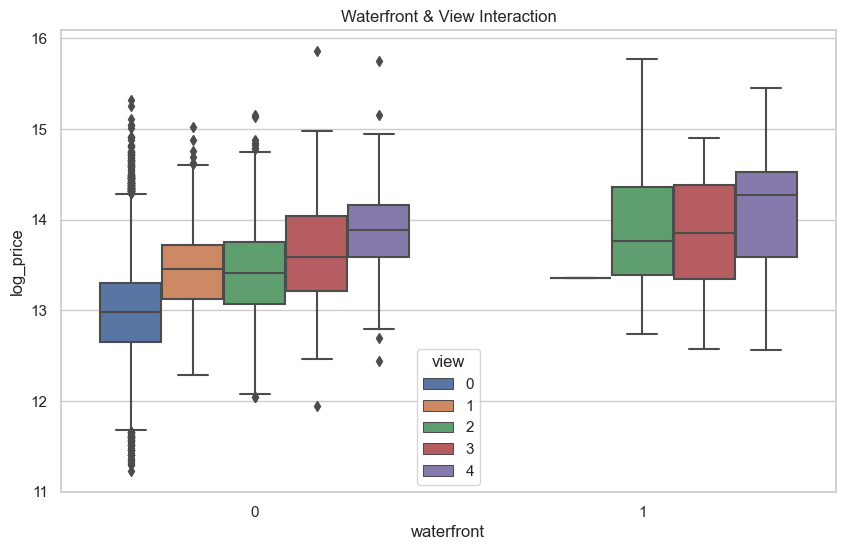

In [39]:
#14.2 Waterfront + View Interaction
sns.boxplot(
    x="waterfront",
    y="log_price",
    hue="view",
    data=df
)
plt.title("Waterfront & View Interaction")
plt.show()


In [40]:
#15.1 Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop(columns=["log_price"]).select_dtypes(include=np.number)
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data.sort_values("VIF", ascending=False).head(10)


,feature,VIF
22,lat_long,4.998864e+07
9,lat,4.969778e+07
10,long,4.864230e+07
13,year_sold,4.833816e+07
17,log_sqft_living,5.696258e+03
20,above_ratio,4.253700e+02
1,bathrooms,1.796547e+02
19,bath_per_bed,1.597257e+02
7,grade,1.477827e+02
0,bedrooms,1.116208e+02


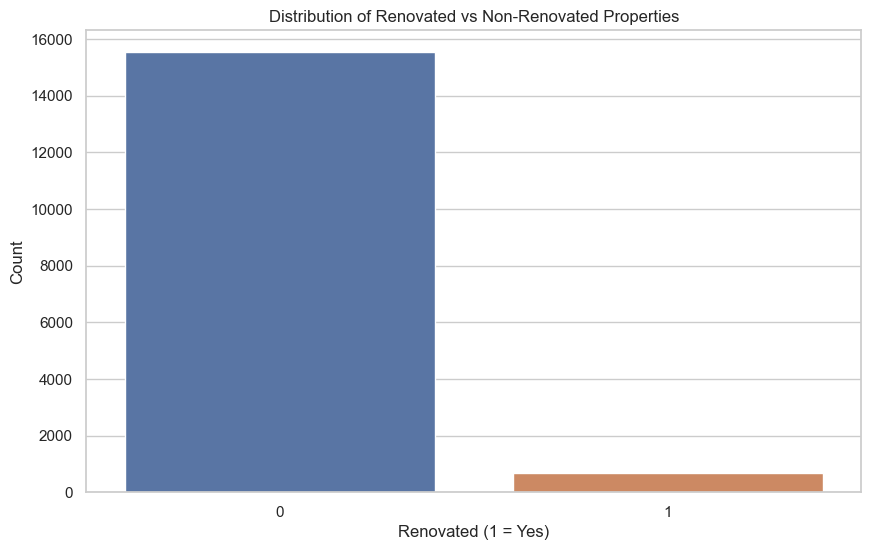

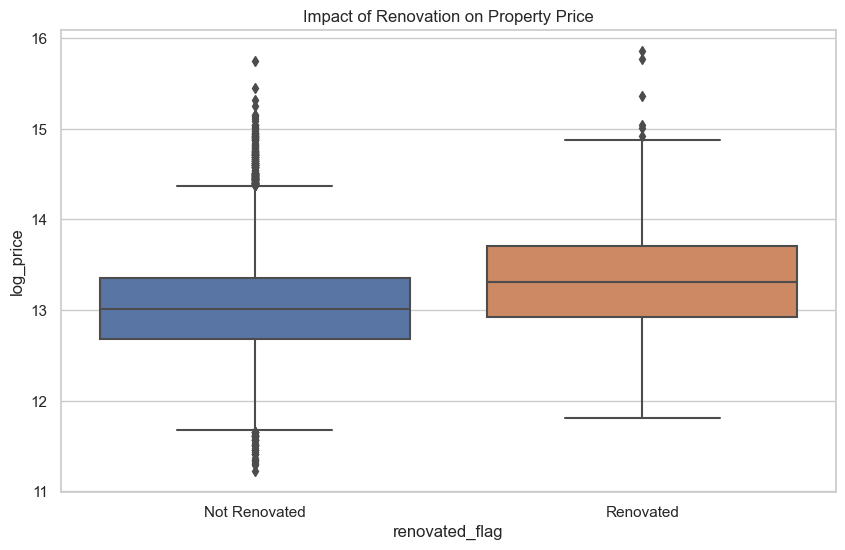

In [41]:
# Renovation Flag

#Distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="renovated_flag", data=df)
plt.title("Distribution of Renovated vs Non-Renovated Properties")
plt.xlabel("Renovated (1 = Yes)")
plt.ylabel("Count")
plt.show()

# Price Impact
sns.boxplot(
    x="renovated_flag",
    y="log_price",
    data=df
)
plt.xticks([0,1], ["Not Renovated", "Renovated"])
plt.title("Impact of Renovation on Property Price")
plt.show()



/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


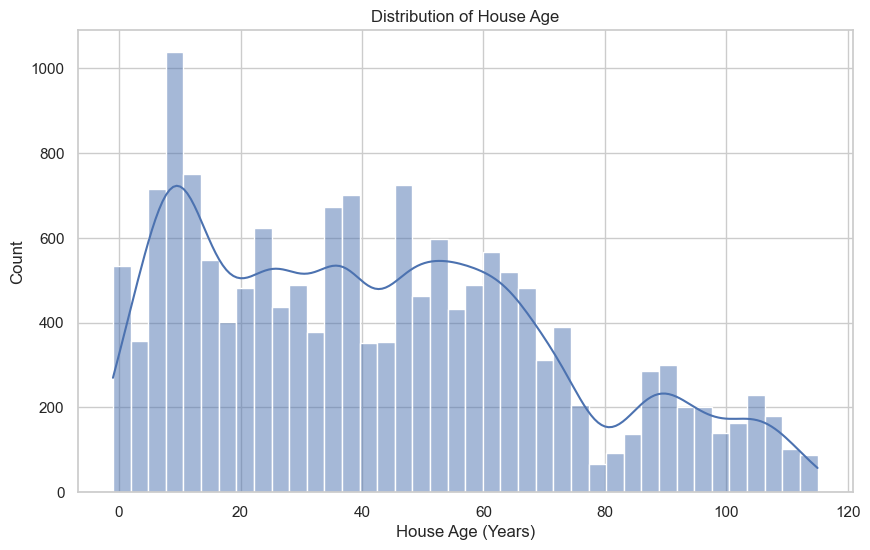

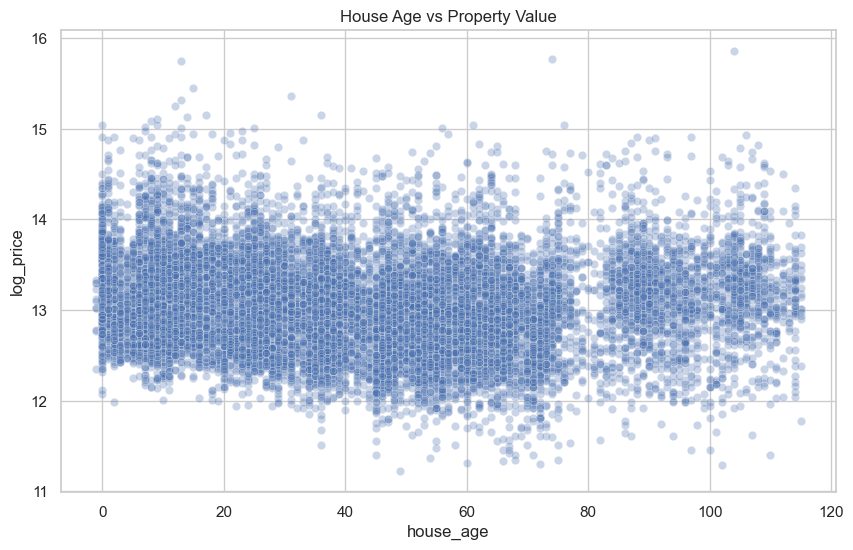

In [42]:
# House Age
sns.histplot(df["house_age"], bins=40, kde=True)
plt.title("Distribution of House Age")
plt.xlabel("House Age (Years)")
plt.show()

# Relationship with Price
sns.scatterplot(
    x="house_age",
    y="log_price",
    data=df,
    alpha=0.3
)
plt.title("House Age vs Property Value")
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


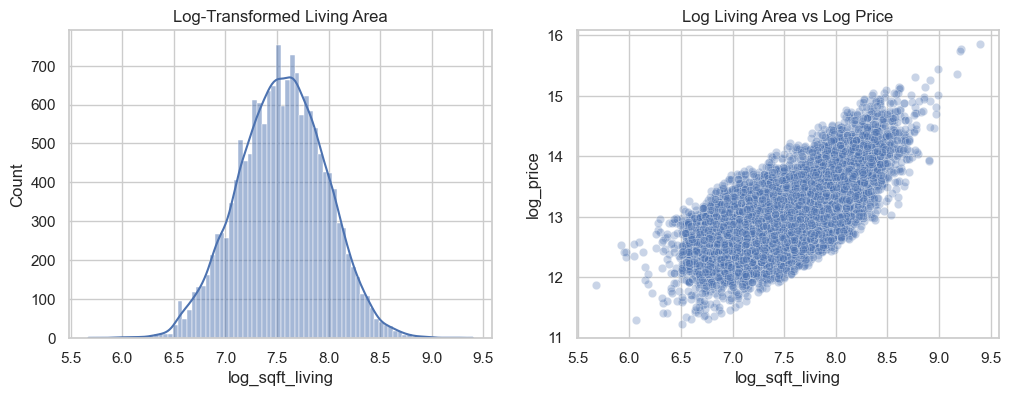

In [43]:
# Log Living Area (log_sqft_living)
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df["log_sqft_living"], kde=True, ax=ax[0])
ax[0].set_title("Log-Transformed Living Area")

sns.scatterplot(
    x="log_sqft_living",
    y="log_price",
    data=df,
    alpha=0.3,
    ax=ax[1]
)
ax[1].set_title("Log Living Area vs Log Price")

plt.show()


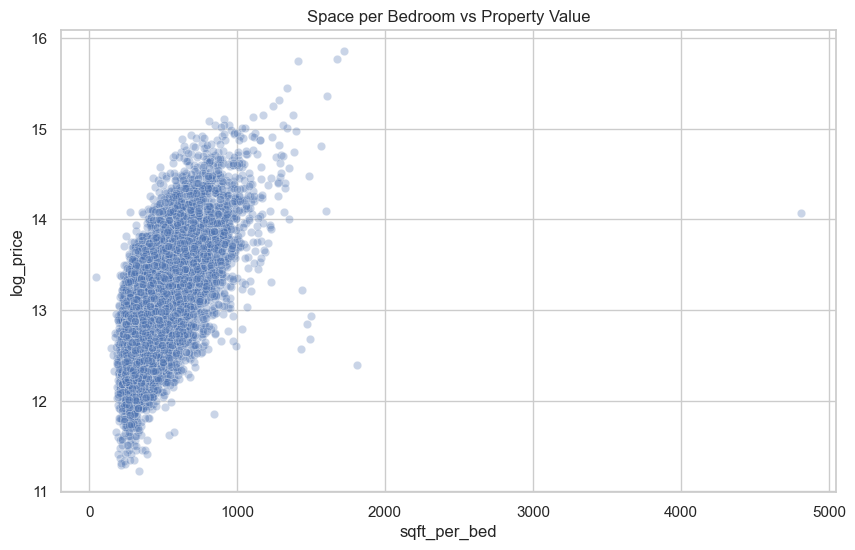

In [44]:
# Space Efficiency (sqft_per_bed)
sns.scatterplot(
    x="sqft_per_bed",
    y="log_price",
    data=df,
    alpha=0.3
)
plt.title("Space per Bedroom vs Property Value")
plt.show()

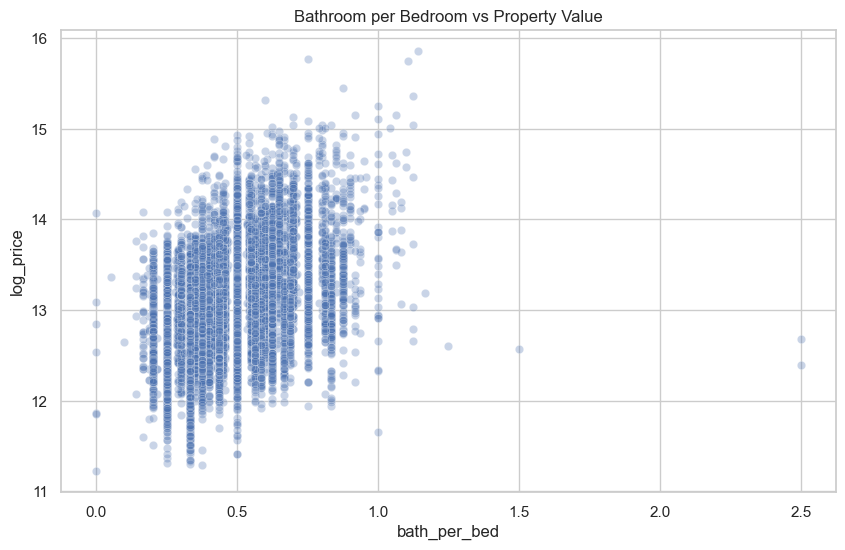

In [45]:
# Bathroom Density ( bath_per_bed )
sns.scatterplot(
    x="bath_per_bed",
    y="log_price",
    data=df,
    alpha=0.3
)
plt.title("Bathroom per Bedroom vs Property Value")
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


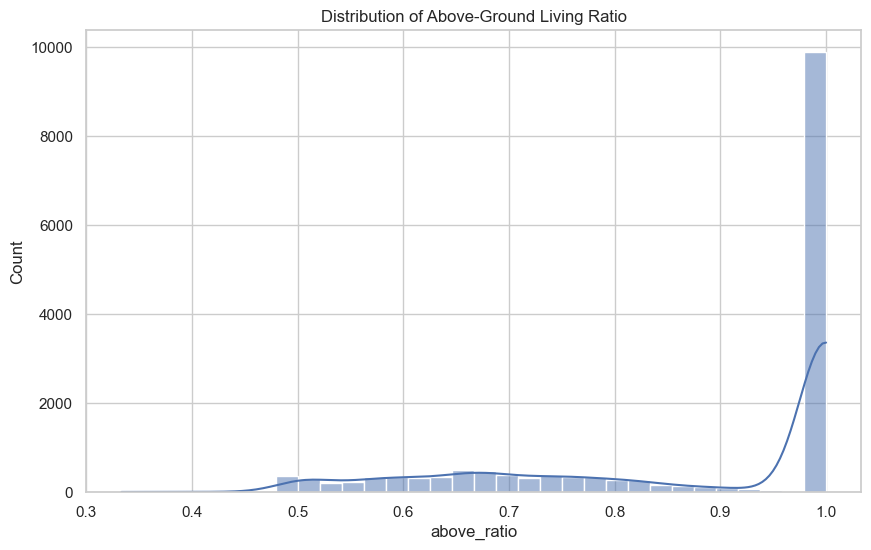

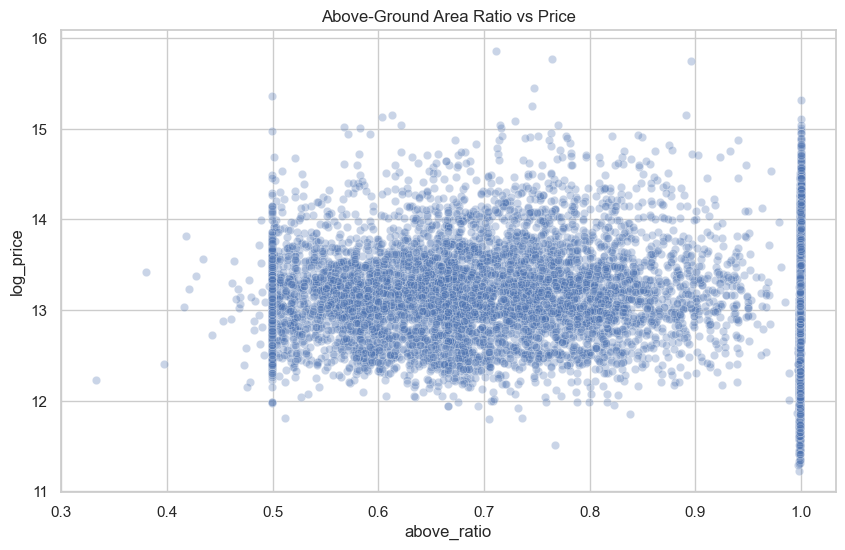

In [46]:
# Above-Ground Ratio (Above-Ground Ratio)
sns.histplot(df["above_ratio"], kde=True)
plt.title("Distribution of Above-Ground Living Ratio")
plt.show()
sns.scatterplot(
    x="above_ratio",
    y="log_price",
    data=df,
    alpha=0.3
)
plt.title("Above-Ground Area Ratio vs Price")
plt.show()


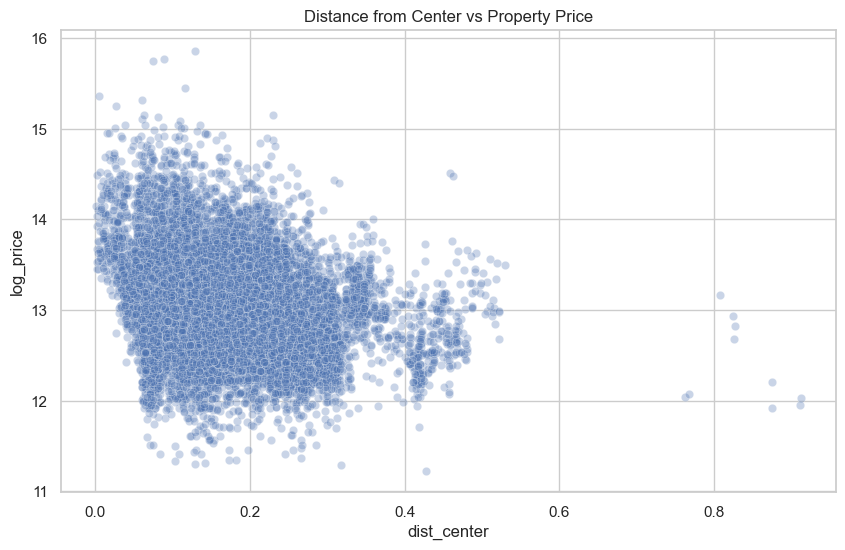

In [47]:
# Distance from City Center (dist_center)
sns.scatterplot(
    x="dist_center",
    y="log_price",
    data=df,
    alpha=0.3
)
plt.title("Distance from Center vs Property Price")
plt.show()


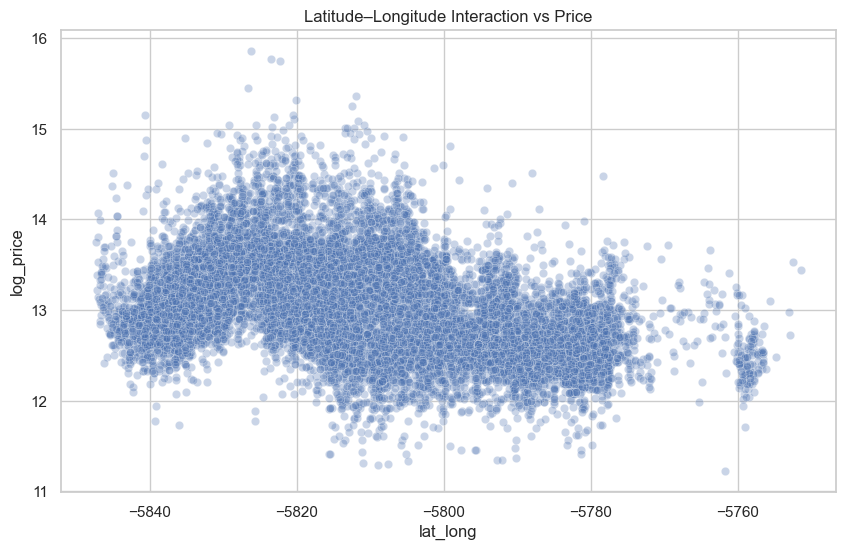

In [48]:
# Geographic Interaction (lat_long)
sns.scatterplot(
    x="lat_long",
    y="log_price",
    data=df,
    alpha=0.3
)
plt.title("Latitude–Longitude Interaction vs Price")
plt.show()


In [49]:
!pip install geopandas shapely pyproj


In [50]:
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [51]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["long"], df["lat"]),
    crs="EPSG:4326"   # WGS84
)
city_center = Point(
    gdf["long"].median(),
    gdf["lat"].median()
)

center_gdf = gpd.GeoDataFrame(
    geometry=[city_center],
    crs="EPSG:4326"
)
gdf_m = gdf.to_crs(epsg=3857)
center_m = center_gdf.to_crs(epsg=3857)

gdf_m["dist_center_km"] = (
    gdf_m.geometry.distance(center_m.geometry.iloc[0]) / 1000
)
gdf_m["zone_center"] = pd.cut(
    gdf_m["dist_center_km"],
    bins=[0, 5, 15, np.inf],
    labels=["Prime", "Urban", "Suburban"]
)



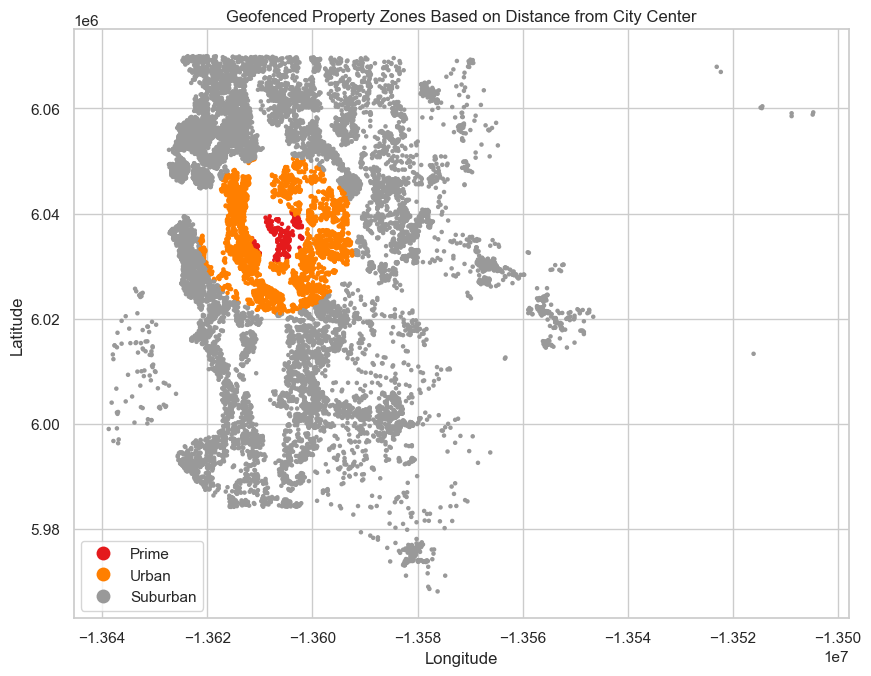

In [52]:
# PROPERTY LOCATIONS + GEOFENCED ZONES (CORE MAP)

import geopandas as gpd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

gdf_m.plot(
    column="zone_center",
    categorical=True,
    legend=True,
    cmap="Set1",
    markersize=5,
    ax=ax
)

ax.set_title("Geofenced Property Zones Based on Distance from City Center")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


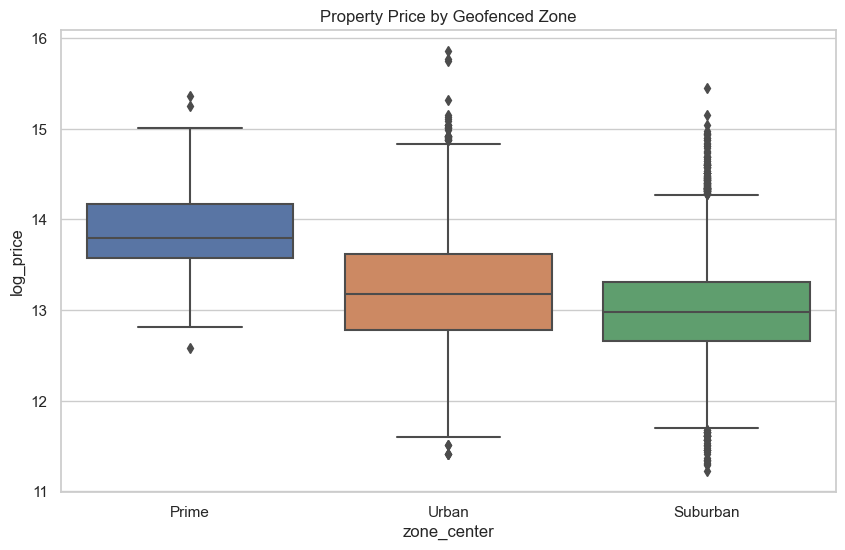

In [53]:
# Geofence vs Price 
sns.boxplot(
    x="zone_center",
    y="log_price",
    data=gdf_m
)
plt.title("Property Price by Geofenced Zone")
plt.show()



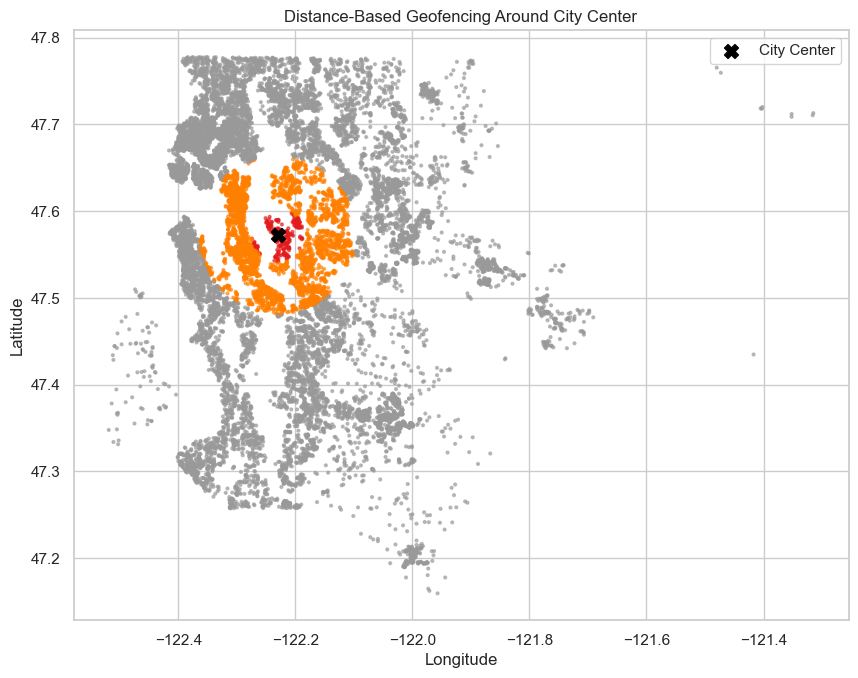

In [54]:
# CITY CENTER + GEOFENCE RINGS
# Convert back to geographic CRS for plotting
gdf_plot = gdf_m.to_crs(epsg=4326)
center_plot = center_gdf.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot properties
gdf_plot.plot(
    column="zone_center",
    cmap="Set1",
    markersize=4,
    legend=True,
    ax=ax,
    alpha=0.6
)

# Plot city center
center_plot.plot(
    ax=ax,
    color="black",
    marker="X",
    markersize=100,
    label="City Center"
)

ax.set_title("Distance-Based Geofencing Around City Center")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.legend()
plt.show()



In [55]:
zone_dummies = pd.get_dummies(gdf_m["zone_center"], prefix="zone")
gdf_m = pd.concat([gdf_m, zone_dummies], axis=1)





In [56]:
import numpy as np

def kmeans_numpy(X, k, max_iters=100, random_state=42):
    np.random.seed(random_state)

    # randomly pick k initial centers
    centers = X[np.random.choice(len(X), k, replace=False)]

    for _ in range(max_iters):
        # compute distances
        distances = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)

        # assign clusters
        labels = np.argmin(distances, axis=1)

        # update centers
        new_centers = np.array([
            X[labels == i].mean(axis=0) if np.any(labels == i) else centers[i]
            for i in range(k)
        ])

        # convergence check
        if np.allclose(centers, new_centers):
            break

        centers = new_centers

    return labels, centers


In [57]:
coords = np.column_stack([gdf["lat"].values, gdf["long"].values])

labels, centers = kmeans_numpy(coords, k=6)

gdf_m["market_cluster"] = labels


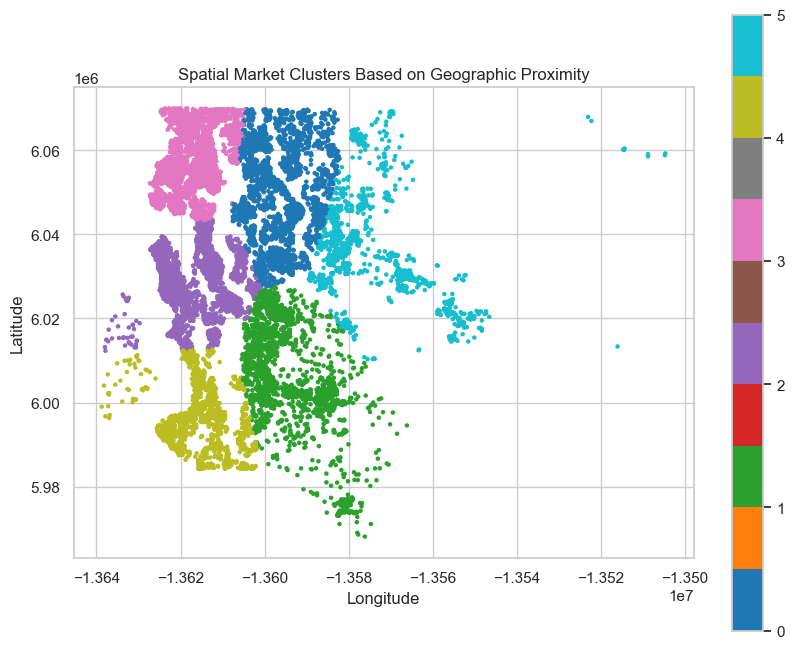

In [58]:
# CLUSTER-BASED MARKET SEGMENTS
fig, ax = plt.subplots(figsize=(10, 8))

gdf_m.plot(
    column="market_cluster",
    cmap="tab10",
    legend=True,
    markersize=5,
    ax=ax
)

ax.set_title("Spatial Market Clusters Based on Geographic Proximity")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()


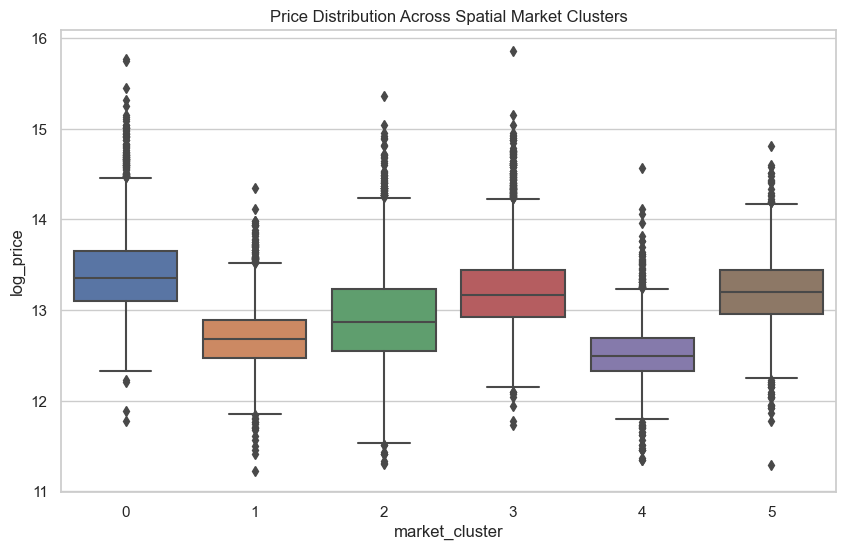

In [59]:
# Price by cluster
sns.boxplot(
    x="market_cluster",
    y="log_price",
    data=gdf_m
)
plt.title("Price Distribution Across Spatial Market Clusters")
plt.show()


In [ ]:
import zipfile
import os

ZIP_PATH = "sat_images.zip"
EXTRACT_DIR = "extracted"

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)


In [ ]:
IMAGE_DIR = os.path.join(EXTRACT_DIR, "sat_images_esri")


In [ ]:
image_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.endswith(".png") and not f.startswith("._")
]

print("Total valid images:", len(image_files))


In [ ]:
 df = df.reset_index(drop=True)
df["img_id"] = df.index
print(df.columns)
print(df[["img_id"]].head())


In [ ]:
# BASIC IMAGE LOADING & DISPLAY

import cv2
import matplotlib.pyplot as plt
import random

def show_sample_images(img_ids, title):
    plt.figure(figsize=(12,4))
    for i, img_id in enumerate(img_ids):
        img = cv2.imread(os.path.join(IMAGE_DIR, f"{img_id}.png"))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

sample_ids = random.sample(list(df["img_id"]), 5)
show_sample_images(sample_ids, "Sample Satellite Images")


In [ ]:
# EXTRACT INTERPRETABLE VISUAL FEATURES
import numpy as np

def extract_visual_features(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0

    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]

    green_ratio = np.mean((G > R) & (G > B))
    blue_ratio = np.mean((B > R) & (B > G))

    gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    concrete_ratio = np.mean(gray > 150)

    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size

    texture = np.var(gray)

    return green_ratio, blue_ratio, concrete_ratio, edge_density, texture


In [ ]:
import os

IMAGE_DIR = "extracted/sat_images_esri"

valid_img_ids = sorted([
    int(f.replace(".png", ""))
    for f in os.listdir(IMAGE_DIR)
    if f.endswith(".png") and not f.startswith("._")
])

print("Total valid images:", len(valid_img_ids))
print("Missing images:", len(df) - len(valid_img_ids))


In [ ]:
df = df[df["img_id"].isin(valid_img_ids)].copy()
df = df.sort_values("img_id").reset_index(drop=True)

print("Filtered dataframe rows:", len(df))


In [ ]:
from tqdm import tqdm

visual_features = []

for img_id in tqdm(df["img_id"]):
    path = os.path.join(IMAGE_DIR, f"{img_id}.png")
    visual_features.append(extract_visual_features(path))

vis_df = pd.DataFrame(
    visual_features,
    columns=[
        "green_ratio",
        "blue_ratio",
        "concrete_ratio",
        "edge_density",
        "texture"
    ]
)

df_vis = pd.concat([df.reset_index(drop=True), vis_df], axis=1)


In [ ]:
# DISTRIBUTION ANALYSIS (VISUAL EDA)

#Green cover
import seaborn as sns

sns.histplot(df_vis["green_ratio"], kde=True)
plt.title("Distribution of Green Cover")
plt.show()


In [ ]:
# Built-up density
sns.histplot(df_vis["concrete_ratio"], kde=True)
plt.title("Distribution of Built-up Density")
plt.show()


In [ ]:

#Greenery vs Price
sns.scatterplot(
    x="green_ratio",
    y="log_price",
    data=df_vis,
    alpha=0.4
)
plt.title("Green Cover vs Property Value")
plt.xlabel("Green Ratio")
plt.ylabel("Log Price")
plt.show()



In [ ]:
# Water Presence Premium
df_vis["water_nearby"] = df_vis["blue_ratio"] > 0.02

sns.boxplot(
    x="water_nearby",
    y="log_price",
    data=df_vis
)
plt.xticks([0,1], ["No Water", "Water Nearby"])
plt.title("Water Proximity vs Property Value")
plt.show()


In [ ]:
# Concrete Density vs Price
sns.scatterplot(
    x="concrete_ratio",
    y="log_price",
    data=df_vis,
    alpha=0.4
)
plt.title("Built-up Density vs Property Price")
plt.show()


In [ ]:
# Road Density vs Price
sns.scatterplot(
    x="edge_density",
    y="log_price",
    data=df_vis,
    alpha=0.4
)
plt.title("Road / Edge Density vs Property Price")
plt.show()


In [ ]:
# CORRELATION HEATMAP
corr = df_vis[
    ["log_price","green_ratio","blue_ratio",
     "concrete_ratio","edge_density","texture"]
].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Visual Signals and Price")
plt.show()


In [ ]:
# IMAGE-BASED COMPARISON
high_price = df_vis.nlargest(5, "log_price")["img_id"]
low_price  = df_vis.nsmallest(5, "log_price")["img_id"]

show_sample_images(high_price, "High-Value Property Neighborhoods")
show_sample_images(low_price, "Low-Value Property Neighborhoods")
